In [2]:
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
import os
import re
import seaborn as sns
import json

In [3]:
# 1. Load the DataFrames
race_data = pd.read_csv("race_data.csv")
drop_data = pd.read_csv("drop_data.csv")

# Ensure Datetime is a proper datetime object
drop_data['Datetime'] = pd.to_datetime(drop_data['Datetime'])

# 2. Load the Dictionaries
with open("mapping_dicts.json", "r") as f:
    mappings = json.load(f)

race_to_id = mappings["race_to_id"]
batch_to_id = mappings["batch_to_id"]

# JSON saves dictionary keys as strings. We need to convert them back to integers
id_to_race = {int(k): v for k, v in mappings["id_to_race"].items()}
id_to_batch = {int(k): v for k, v in mappings["id_to_batch"].items()}

print("Data and Dictionaries loaded successfully!")
print(f"Number of tracking races: {len(id_to_race)}")

Data and Dictionaries loaded successfully!
Number of tracking races: 13


In [4]:
model_data = drop_data.dropna(subset=['this_batch_dem_proportion']).copy()
race_idx = model_data['race_id'].values 
n_races = len(race_data)
b_rt_observed = model_data['this_batch_dem_proportion'].values
batch_sizes = model_data['this_batch_total_votes'].values
baseline = model_data['baseline_dem_proportion'].values

In [5]:
with pm.Model() as election_model_v2:
    
    # 1. Hyperparameters
    # Variance between races
    sigma_r = pm.HalfNormal('sigma_r', sigma=0.05)     
    
    # The global shift parameters
    mu_g = pm.Normal('mu_g', mu=0.001, sigma=0.01) #JUST changed sigma from 0.05 and ran everything      
    sigma_g = pm.HalfNormal('sigma_g', sigma=0.01)    
    
    # Observation noise for a single batch drop
    sigma_batch = pm.HalfNormal('sigma_batch', sigma=0.31)

    # 2. Race-Specific Latent State (Non-centered parameterization)
    z_r = pm.Normal('z_r', mu=0.0, sigma=1.0, shape=n_races)
    
    # s_r is now just the race's specific deviation from the global trend
    s_r = pm.Deterministic('s_r', z_r * sigma_r) 
    
    # 3. Global Latent State (Non-centered parameterization)
    z_g = pm.Normal('z_g', mu=0.0, sigma=1.0)
    s_g = pm.Deterministic('s_g', mu_g + (z_g * sigma_g))

    # 4. Observation Layer 
    # Calculate the expected dem proportion for this specific batch drop
    # using the new perfectly mapped variables
    expected_b = s_r[race_idx] + s_g + baseline
    
    # The likelihood of the data we actually observed
    b_rt = pm.Normal('b_rt', 
                     mu=expected_b, 
                     sigma=sigma_batch / (batch_sizes ** 0.25), 
                     observed=b_rt_observed)

In [ ]:
with election_model_v2:
    # Run the MCMC sampler
    trace_v2 = pm.sample(draws=2000, tune=1000, chains=4, target_accept=0.99, random_seed=42)
    
# Check out the summary of the latent parameters we care about
display(az.summary(trace_v2, var_names=['s_g', 's_r']))

Initializing NUTS using jitter+adapt_diag...


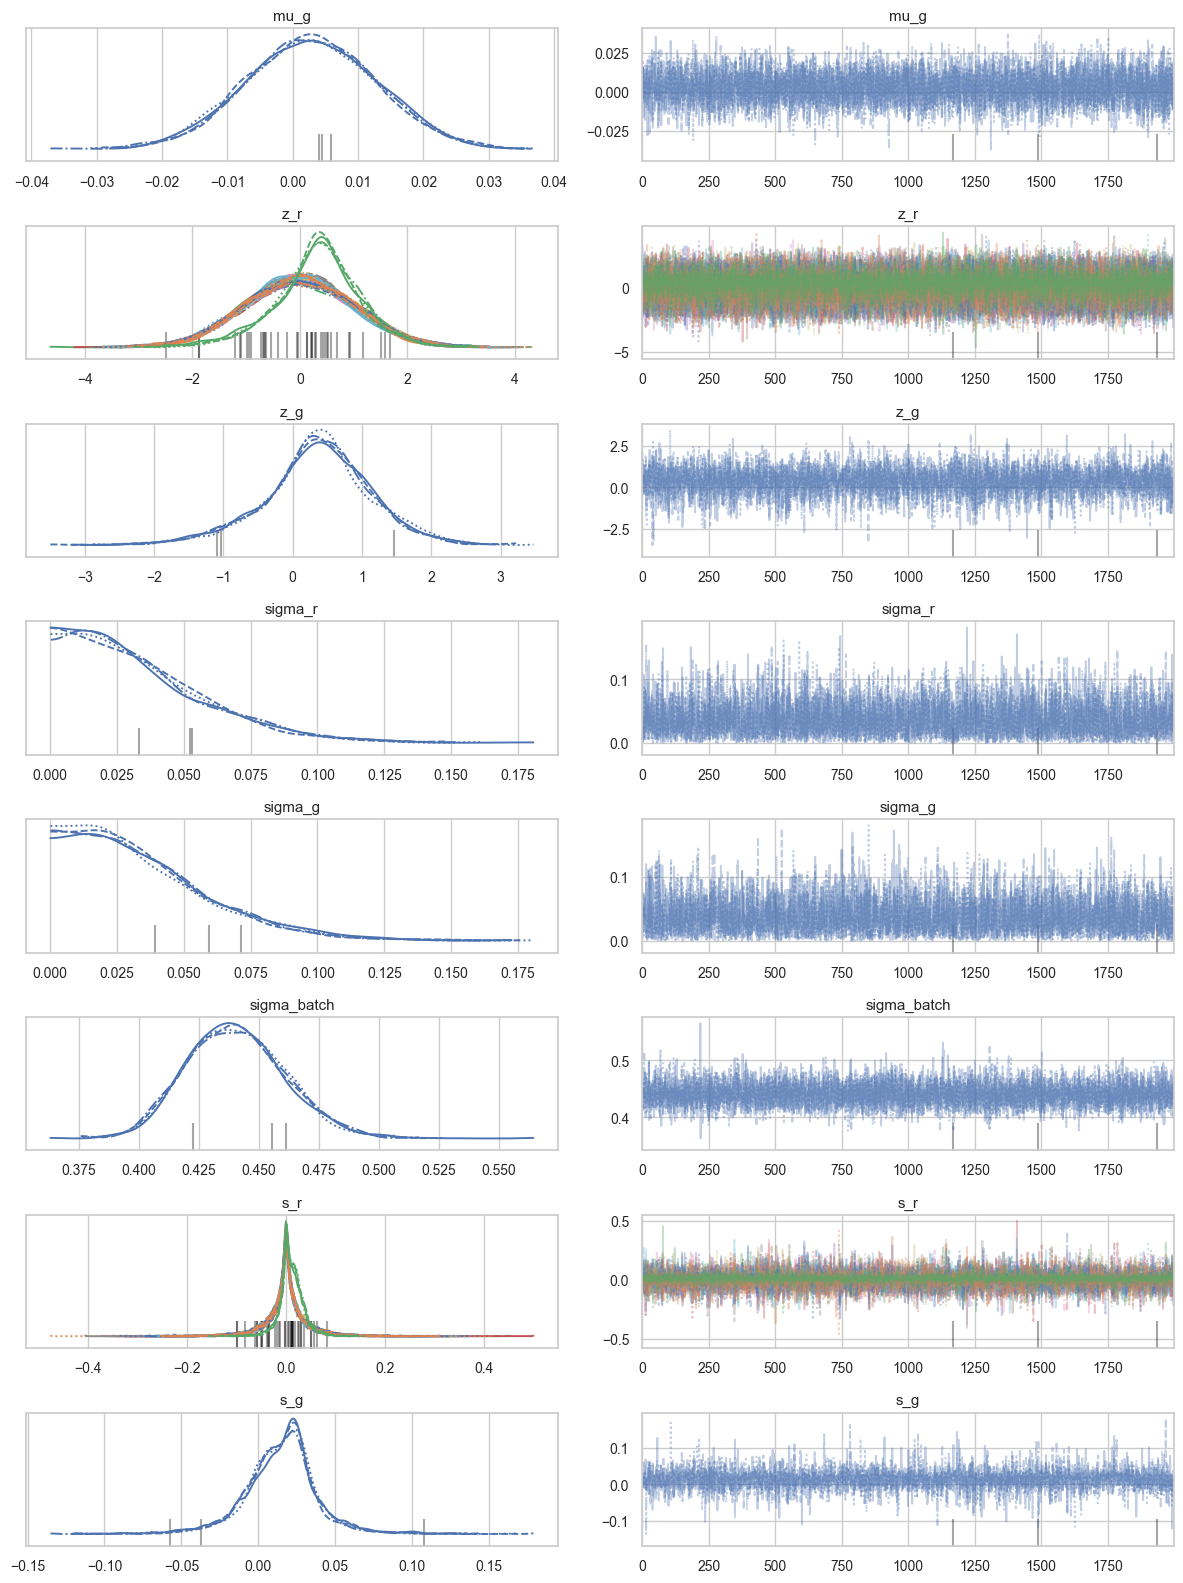

In [ ]:
az.plot_trace(trace_v2)
plt.tight_layout()
plt.show()

In [ ]:
# Dictionary to store the traces for each batch
model_traces = {}

# Get a sorted list of all unique batch IDs in our filtered data
batches = sorted(model_data['batch_id'].unique())

for current_batch in batches:
    print(f"--- Training model up to batch_id: {current_batch} ---")
    
    # 1. Filter data cumulatively up to the current batch
    cumulative_drops = model_data[model_data['batch_id'] <= current_batch]
    
    # 2. Prepare PyMC inputs as numpy arrays for this specific iteration
    obs_race_idx = cumulative_drops['race_id'].values
    obs_b_rt = cumulative_drops['this_batch_dem_proportion'].values
    obs_batch_sizes = cumulative_drops['this_batch_total_votes'].values
    obs_baseline = cumulative_drops['baseline_dem_proportion'].values
    
    with pm.Model() as election_model_v2_seq:
        
        # Hyperparameters
        sigma_r = pm.HalfNormal('sigma_r', sigma=0.0125)     
    
        # The global shift parameters
        mu_g = pm.Normal('mu_g', mu=0.00137, sigma=0.05)      
        sigma_g = pm.HalfNormal('sigma_g', sigma=0.05)    
        
        # Observation scale for a single batch drop
        sigma_batch = pm.HalfNormal('sigma_batch', sigma=0.31)

        # Prior for Degrees of Freedom (Tails thickness)
        # Shifted by 2 to avoid infinite variance territory during sampling
        nu = pm.Exponential('nu', lam=1/5) + 2

        # Race-Specific Latent State (Non-centered)
        z_r = pm.Normal('z_r', mu=0.0, sigma=1.0, shape=n_races)
        s_r = pm.Deterministic('s_r', z_r * sigma_r) 
        
        # Global Latent State (Non-centered)
        z_g = pm.Normal('z_g', mu=0.0, sigma=1.0)
        s_g = pm.Deterministic('s_g', mu_g + (z_g * sigma_g))

        # Observation Layer 
        expected_b = s_r[obs_race_idx] + s_g + obs_baseline
        
        # Dynamic scale adjusted by batch size
        scale_b = sigma_batch / (obs_batch_sizes ** 0.25)
        
        # Changed from pm.Normal to pm.StudentT to fix underdispersion
        b_rt = pm.StudentT('b_rt', 
                           nu=nu,
                           mu=expected_b, 
                           sigma=scale_b, 
                           observed=obs_b_rt)
        
        # Sample the posterior
        trace = pm.sample(
            draws=10000, 
            tune=2000, 
            chains=4, 
            cores=4, 
            target_accept=0.99, 
            progressbar=True,
            random_seed=137
        )
        
    # Store the trace keyed by the batch ID
    model_traces[current_batch] = trace

print("Sequential training complete! Traces are stored in the 'model_traces' dictionary.")

--- Training model up to batch_id: 0 ---


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma_r, mu_g, sigma_g, sigma_batch, nu, z_r, z_g]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 35 seconds.


--- Training model up to batch_id: 1 ---


...

--- Training model up to batch_id: 23 ---


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma_r, mu_g, sigma_g, sigma_batch, nu, z_r, z_g]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 56 seconds.


Sequential training complete! Traces are stored in the 'model_traces' dictionary.


In [ ]:
print("--- Model Diagnostics (Convergence Check) ---")

# We exclude the 'z_r' and 'z_g' raw values, focusing on the core parameters
check_vars = ["mu_g", "sigma_g", "sigma_r", "sigma_batch", "s_g"]

for batch in batches:
    tmp = az.summary(model_traces[batch], var_names=check_vars)
    
    min_ess_bulk = tmp['ess_bulk'].min()
    min_ess_tail = tmp['ess_tail'].min()
    max_r_hat = tmp['r_hat'].max()
    
    print(f"Batch {batch:2} | max r_hat: {max_r_hat:.3f} | min ess_bulk: {min_ess_bulk:4.0f} | min ess_tail: {min_ess_tail:4.0f}")

print("\nIf all r_hats are near 1.0, the model sampled perfectly!")

--- Model Diagnostics (Convergence Check) ---
Batch  0 | max r_hat: 1.000 | min ess_bulk: 4506 | min ess_tail: 3563
Batch  1 | max r_hat: 1.000 | min ess_bulk: 2850 | min ess_tail: 3279
Batch  2 | max r_hat: 1.000 | min ess_bulk: 4040 | min ess_tail: 3585
Batch  3 | max r_hat: 1.000 | min ess_bulk: 2964 | min ess_tail: 3178
Batch  4 | max r_hat: 1.000 | min ess_bulk: 2989 | min ess_tail: 2927
Batch  5 | max r_hat: 1.000 | min ess_bulk: 2511 | min ess_tail: 2808
Batch  6 | max r_hat: 1.000 | min ess_bulk: 2477 | min ess_tail: 2898
Batch  7 | max r_hat: 1.000 | min ess_bulk: 2041 | min ess_tail: 1471
Batch  8 | max r_hat: 1.000 | min ess_bulk: 2842 | min ess_tail: 3177
Batch  9 | max r_hat: 1.000 | min ess_bulk: 3355 | min ess_tail: 3514
Batch 10 | max r_hat: 1.000 | min ess_bulk: 3175 | min ess_tail: 3577
Batch 11 | max r_hat: 1.000 | min ess_bulk: 3789 | min ess_tail: 2625
Batch 12 | max r_hat: 1.000 | min ess_bulk: 2974 | min ess_tail: 3143
Batch 13 | max r_hat: 1.000 | min ess_bulk: 

In [ ]:
import os

# Create directory if it doesn't exist
os.makedirs("v2_traces", exist_ok=True)

print("Saving traces...")

for current_batch in batches:
    file_path = f"v2_traces/trace_batch_{current_batch}.nc"
    
    # Check if the file already exists to explicitly note we are overwriting
    if os.path.exists(file_path):
        os.remove(file_path) # Safely remove the old one first just in case
        
    model_traces[current_batch].to_netcdf(file_path)
    print(f"Saved: {file_path}")

print("All traces successfully saved!")

Saving traces...
Saved: v2_traces/trace_batch_0.nc
Saved: v2_traces/trace_batch_1.nc
Saved: v2_traces/trace_batch_2.nc
Saved: v2_traces/trace_batch_3.nc
Saved: v2_traces/trace_batch_4.nc
Saved: v2_traces/trace_batch_5.nc
Saved: v2_traces/trace_batch_6.nc
Saved: v2_traces/trace_batch_7.nc
Saved: v2_traces/trace_batch_8.nc
Saved: v2_traces/trace_batch_9.nc
Saved: v2_traces/trace_batch_10.nc
Saved: v2_traces/trace_batch_11.nc
Saved: v2_traces/trace_batch_12.nc
Saved: v2_traces/trace_batch_13.nc
Saved: v2_traces/trace_batch_14.nc
Saved: v2_traces/trace_batch_15.nc
Saved: v2_traces/trace_batch_16.nc
Saved: v2_traces/trace_batch_17.nc
Saved: v2_traces/trace_batch_18.nc
Saved: v2_traces/trace_batch_19.nc
Saved: v2_traces/trace_batch_20.nc
Saved: v2_traces/trace_batch_21.nc
Saved: v2_traces/trace_batch_22.nc
Saved: v2_traces/trace_batch_23.nc
All traces successfully saved!


In [ ]:
# import arviz as az

# model_traces = {}

# print("Reloading saved traces from disk...")

# for current_batch in batches:
#     file_path = f"v2_traces/trace_batch_{current_batch}.nc"
    
#     if os.path.exists(file_path):
#         # Load the inference data back in
#         model_traces[current_batch] = az.from_netcdf(file_path)
#         print(f"Successfully loaded: {file_path}")
#     else:
#         print(f"Warning: Expected trace file not found at {file_path}")

# print(f"\nDone! Reloaded {len(model_traces)} traces into 'model_traces'.")

In [ ]:
# Create an array of baselines aligned 0-12 to perfectly match the s_r columns
baseline_array = race_data.sort_values('race_id')['baseline_dem_proportion'].values

extracted_posteriors = {}

for current_batch, trace in model_traces.items():
    
    # 1. Extract the raw multi-dimensional arrays (Adding 'nu' here)
    s_r_raw = trace.posterior["s_r"].values               # Shape: (chains, draws, n_races)
    s_g_raw = trace.posterior["s_g"].values               # Shape: (chains, draws)
    sig_batch_raw = trace.posterior["sigma_batch"].values # Shape: (chains, draws)
    nu_raw = trace.posterior["nu"].values                 # Shape: (chains, draws)
    
    # 2. Flatten the chains and draws together into one long sequence
    s_r_flat = s_r_raw.reshape(-1, s_r_raw.shape[-1]) # Shape: (total_samples, n_races)
    s_g_flat = s_g_raw.flatten()                      # Shape: (total_samples,)
    sig_batch_flat = sig_batch_raw.flatten()          # Shape: (total_samples,)
    nu_flat = nu_raw.flatten()                        # Shape: (total_samples,)
    
    # 3. Calculate the step size to get exactly 1000 draws
    total_samples = len(s_g_flat)
    step = total_samples // 1000
    
    # 4. Slice the arrays evenly and cap at exactly 1000
    s_r_1000 = s_r_flat[::step][:1000]
    s_g_1000 = s_g_flat[::step][:1000]
    sig_batch_1000 = sig_batch_flat[::step][:1000]
    nu_1000 = nu_flat[::step][:1000]
    
    # 5. Calculate the expected Dem Prop for ALL races
    expected_b_1000 = s_r_1000 + s_g_1000[:, np.newaxis] + baseline_array
    
    # Store the parameters (Now including nu)
    extracted_posteriors[current_batch] = {
        "expected_b": expected_b_1000,   # Shape: (1000, n_races)
        "sigma_batch": sig_batch_1000,   # Shape: (1000,)
        "nu": nu_1000                    # Shape: (1000,)
    }

print("Evenly spaced posterior draws extracted and stored in 'extracted_posteriors'.")

Evenly spaced posterior draws extracted and stored in 'extracted_posteriors'.


In [ ]:
trace.posterior["nu"].values.flatten()[::8][:1000].mean()

np.float64(4.58695501739401)

In [67]:
# Use NumPy's random generator (seed for reproducibility)
rng = np.random.default_rng(seed=42)

final_outcomes_dict = {}
simulated_future_batches = {} # We'll still save this in case your plotting code needs it!

concentration_scale = 10.0 
drift_slope = 0.00  # The linear variance growth per step k
total_batches = len(batches)

print("Projecting final totals for all batches...")

for i, current_batch in enumerate(batches):
    n_remaining = total_batches - i - 1
    
    # --- 1. THE CLEAN CARRY-FORWARD DATA PREP ---
    cumulative_data = model_data[model_data['batch_id'] <= current_batch]
    current_data = cumulative_data.sort_values('batch_id').drop_duplicates(subset=['race_id'], keep='last')
    
    current_dem_votes = np.zeros(n_races)
    votes_remaining = np.zeros(n_races)
    
    current_race_indices = current_data['race_id'].values
    current_dem_votes[current_race_indices] = current_data['up_to_this_batch_dem_votes'].values
    
    calc_remaining = current_data['final_total_votes'] - current_data['up_to_this_batch_total_votes']
    # print(np.mean((calc_remaining - current_data['estimated_votes_remaining']) / calc_remaining))
    # calc_remaining = current_data['estimated_votes_remaining']  ## NEW
    votes_remaining[current_race_indices] = np.maximum(0, calc_remaining.values)
    # --------------------------------------------
    
    if n_remaining > 0:
        # --- 2. SIMULATE FUTURE BATCH SIZES (DIRICHLET) ---
        # --- 2. SIMULATE FUTURE BATCH SIZES (DIRICHLET) ---
        log_weights = np.log(1 + 1 / (np.arange(1, n_remaining + 1) - 0.5))
        alphas = log_weights * concentration_scale
        
        dirichlet_draws = rng.dirichlet(alpha=alphas, size=(1000, n_races))
        dirichlet_draws = dirichlet_draws.transpose(0, 2, 1) 
        
        # Keep this raw and untouched so your total vote counts remain mathematically accurate
        sim_batch_sizes = dirichlet_draws * votes_remaining
        
        # --- 3. DYNAMIC SCALE & NU CALCULATION ---
        exp_b_1000 = extracted_posteriors[current_batch]['expected_b']
        sig_batch_1000 = extracted_posteriors[current_batch]['sigma_batch']
        nu_1000 = extracted_posteriors[current_batch]['nu']
        
        exp_b_reshaped = exp_b_1000[:, np.newaxis, :]               
        sig_batch_reshaped = sig_batch_1000[:, np.newaxis, np.newaxis] 
        nu_reshaped = nu_1000[:, np.newaxis, np.newaxis]               
        
        # Create a separate array for calculating variance penalties
        # This prevents variance explosion without altering the actual vote tallies
        variance_calc_sizes = sim_batch_sizes.copy()
        
        # Smoothly floor the variance scale size to a realistic minimum baseline (e.g., 500 votes)
        # If a batch is simulated to be smaller than 500, treat its variance penalty as if it were 500.
        safe_sim_sizes = np.maximum(variance_calc_sizes, 1000.0)
        
        # A. Apply the 1/B^0.25 penalty safely
        base_sigma = sig_batch_reshaped / (safe_sim_sizes ** 0.25)
        
        # B. Apply the drift based on horizon (k)
        k_values = np.arange(1, n_remaining + 1)[np.newaxis, :, np.newaxis]
        total_sigma = base_sigma * np.sqrt(1 + drift_slope * k_values)
        
        # --- 4. SIMULATE DEMOCRATIC PROPORTIONS (STUDENT T) ---
        standard_t_draws = rng.standard_t(df=nu_reshaped, size=(1000, n_remaining, n_races))
        sim_dem_rates = exp_b_reshaped + (standard_t_draws * total_sigma)
        sim_dem_rates = np.clip(sim_dem_rates, 0.0, 1.0)
        
        simulated_future_batches[current_batch] = sim_dem_rates
        
        # --- 5. CALCULATE FINAL VOTES ---
        # Uses the true sim_batch_sizes, fixing the RMSE jump!
        added_dem_votes_per_batch = sim_batch_sizes * sim_dem_rates
        total_added_dem_votes = added_dem_votes_per_batch.sum(axis=1)
        
        final_simulated_dem_votes = current_dem_votes + total_added_dem_votes
        final_outcomes_dict[current_batch] = final_simulated_dem_votes
    else:
        # Final batch: Just tile the most recent current_dem_votes 1000 times
        final_outcomes_dict[current_batch] = np.tile(current_dem_votes, (1000, 1))
        simulated_future_batches[current_batch] = None

print("Projection complete! Simulated final Dem Vote counts stored in 'final_outcomes_dict'.")

Projecting final totals for all batches...
Projection complete! Simulated final Dem Vote counts stored in 'final_outcomes_dict'.


Plotting projections with bounds...


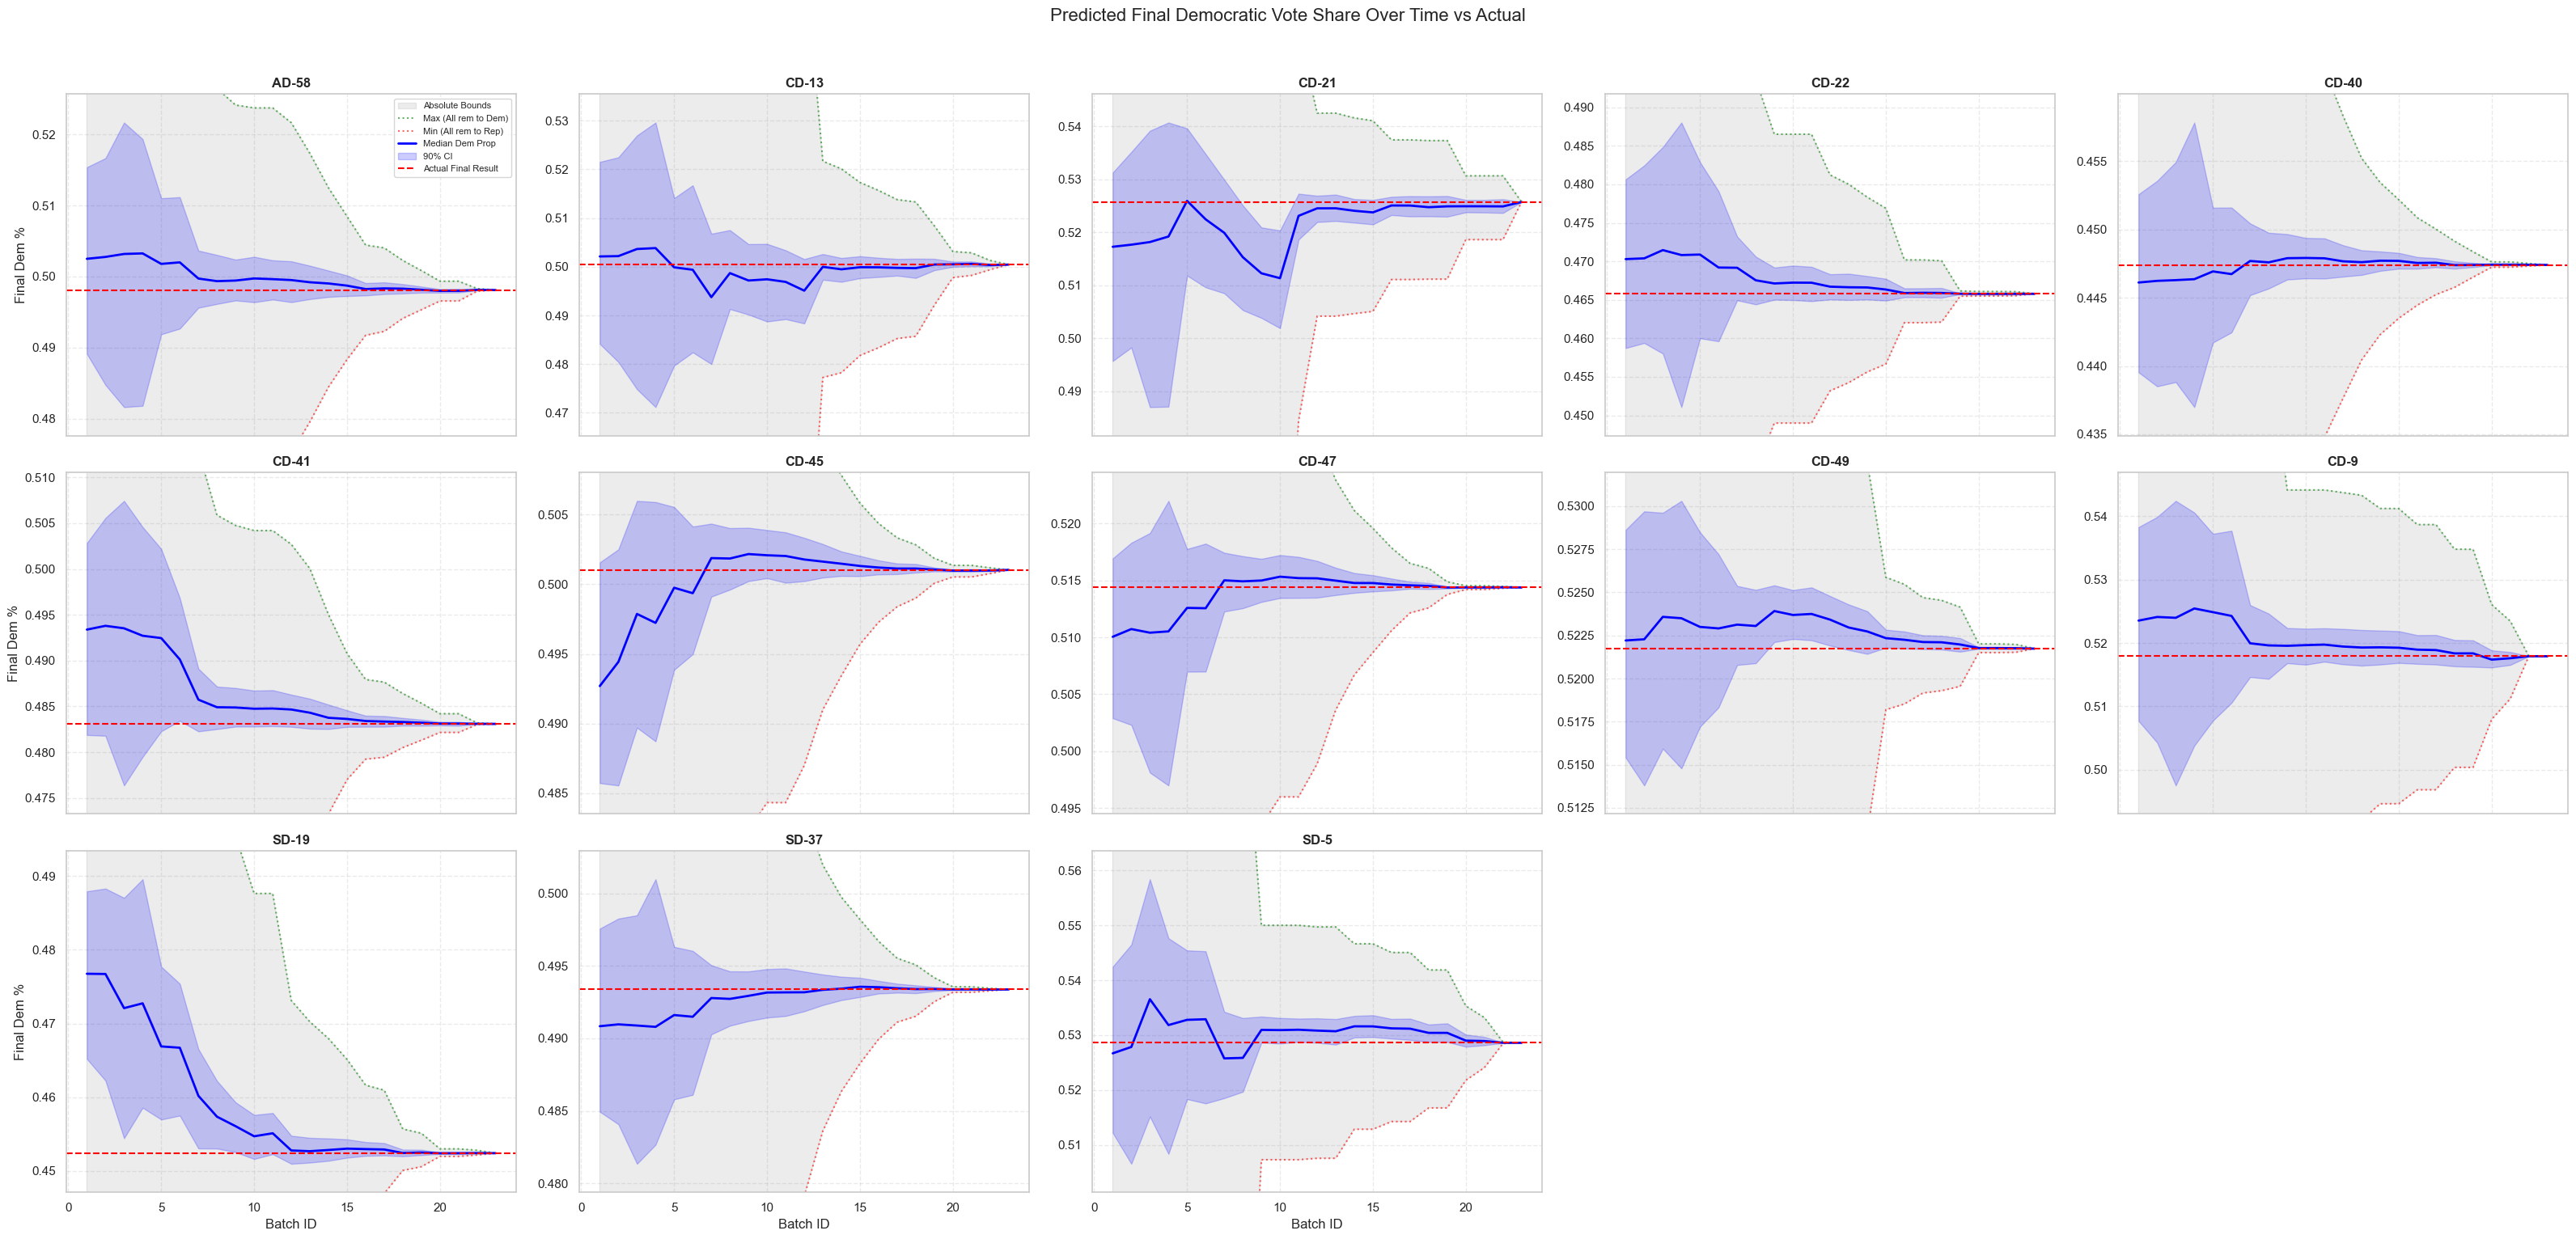

In [68]:
# 1. Variables
batch_list = list(final_outcomes_dict.keys())
race_denominators = race_data.sort_values('race_id')['final_total_votes'].values

# 2. Set up the plot grid
cols = 5
rows = int(np.ceil(n_races / cols))
fig, axes = plt.subplots(rows, cols, figsize=(32, 5 * rows), sharex=True)
axes = axes.flatten()

print("Plotting projections with bounds...")

for race_idx in range(n_races):
    ax = axes[race_idx]
    race_name = id_to_race[race_idx]
    
    race_denominator = race_denominators[race_idx]
    
    p05, p50, p95 = [], [], []
    min_bounds, max_bounds = [], []
    
    for b in batch_list:
        # Extract percentiles and convert to proportions
        sims_prop = final_outcomes_dict[b][:, race_idx] / race_denominator
        
        p05.append(np.percentile(sims_prop, 5))
        p50.append(np.percentile(sims_prop, 50))
        p95.append(np.percentile(sims_prop, 95))
        
        # --- NEW: Extract current data up to this batch to find absolute bounds ---
        cum_data = model_data[(model_data['batch_id'] <= b) & (model_data['race_id'] == race_idx)]
        
        if len(cum_data) > 0:
            current_dem = cum_data['up_to_this_batch_dem_votes'].iloc[-1]
            current_total = cum_data['up_to_this_batch_total_votes'].iloc[-1]
        else:
            # Fallback to the starting baseline if this race hasn't updated yet!
            baseline_data = race_data[race_data['race_id'] == race_idx]
            current_dem = baseline_data['baseline_dem_votes'].values[0]
            current_total = baseline_data['baseline_total_votes'].values[0]
            
        rem_votes = race_denominator - current_total
        
        # Min = Dem gets 0% of remaining, Max = Dem gets 100% of remaining
        min_bounds.append(current_dem / race_denominator)
        max_bounds.append((current_dem + rem_votes) / race_denominator)
        # -------------------------------------------------------------------------
        
    # Plotting Bounding Regions First
    ax.fill_between(batch_list[1:], min_bounds[1:], max_bounds[1:], color='gray', alpha=0.15, label='Absolute Bounds')
    ax.plot(batch_list[1:], max_bounds[1:], color='green', linestyle=':', alpha=0.6, label='Max (All rem to Dem)')
    ax.plot(batch_list[1:], min_bounds[1:], color='red', linestyle=':', alpha=0.6, label='Min (All rem to Rep)')

    # Plotting Simulations
    ax.plot(batch_list[1:], p50[1:], color='blue', linewidth=2, label='Median Dem Prop')
    ax.fill_between(batch_list[1:], p05[1:], p95[1:], color='blue', alpha=0.2, label='90% CI')
    
    # Plotting Actual Final Result
    actual_final_prop = race_data[race_data['race_id'] == race_idx]['final_dem_proportion'].values[0]
    ax.axhline(actual_final_prop, color='red', linestyle='--', label='Actual Final Result')
    
    # --- Y-axis Zoom logic based ONLY on the simulations & actual result ---
    sim_min = min(p05[1:])
    sim_max = max(p95[1:])
    
    # We include actual_final_prop so the red dashed line never gets cut off
    plot_min = min(sim_min, actual_final_prop)
    plot_max = max(sim_max, actual_final_prop)
    
    y_range = plot_max - plot_min
    padding = y_range * 0.1 if y_range > 0 else 0.05 
    
    ax.set_ylim(plot_min - padding, plot_max + padding)
    # -------------------------------------------------------------------------
    
    # Formatting
    ax.set_title(f"{race_name}", fontsize=12, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.4)
    
    if race_idx % cols == 0:
        ax.set_ylabel("Final Dem %")
    if race_idx >= (rows - 1) * cols:
        ax.set_xlabel("Batch ID")

# Delete extra empty subplots
for i in range(n_races, len(axes)):
    fig.delaxes(axes[i])

# Legend on the first chart only
axes[0].legend(loc='best', fontsize=8)
plt.suptitle("Predicted Final Democratic Vote Share Over Time vs Actual", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

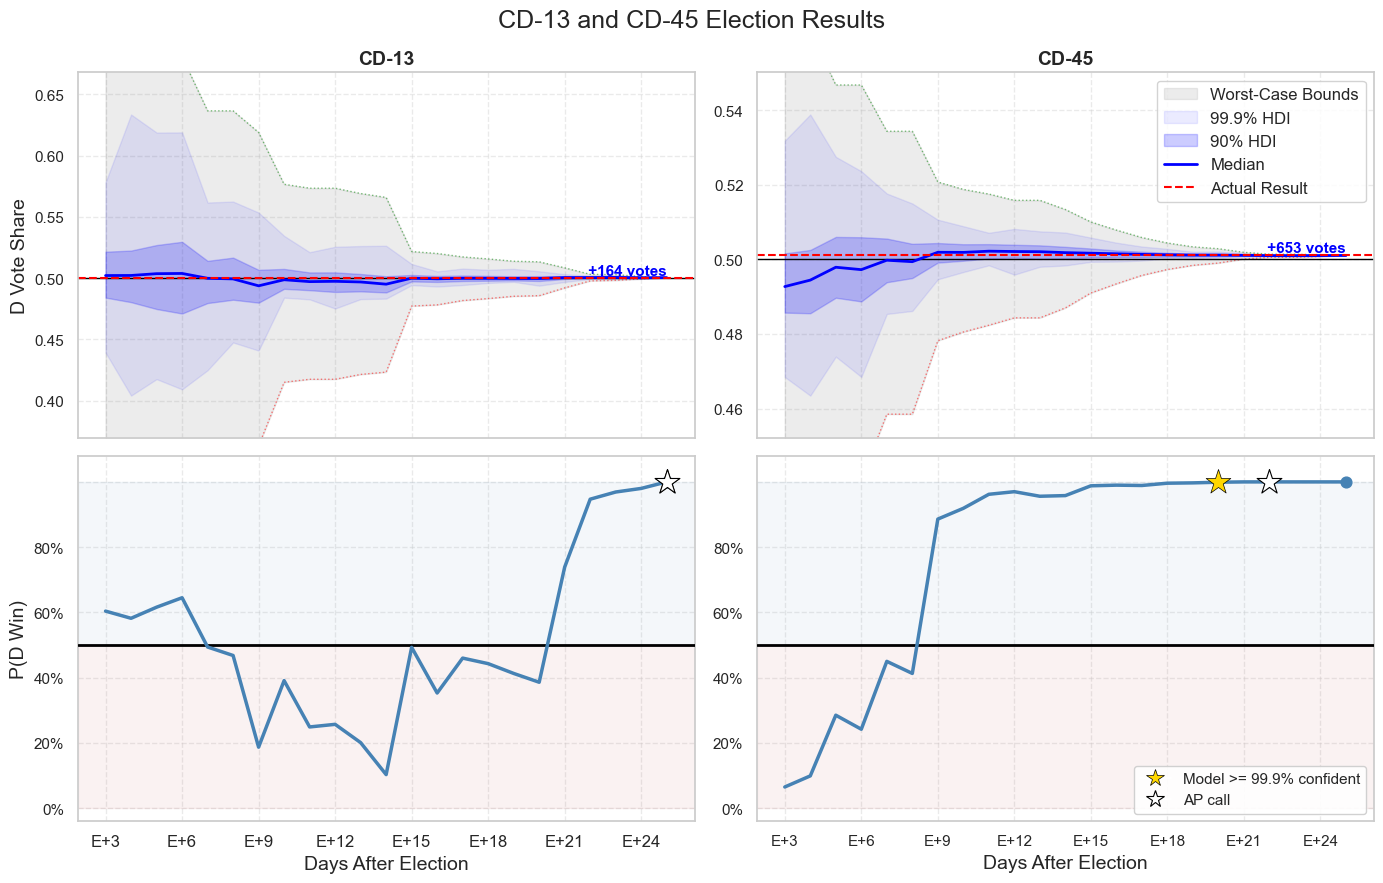

In [69]:
from matplotlib.lines import Line2D

focus_races = ["CD-13", "CD-45"]
focus_indices = [k for k, v in id_to_race.items() if v in focus_races]
focus_indices = sorted(focus_indices, key=lambda i: id_to_race[i])

# AP call batch IDs (verified from drop_data Datetime column)
# CD-45: Nov 27 = E+22 = batch 20
# CD-13: called on last day of counting = batch 23
ap_call_batches = {"CD-13": 23, "CD-45": 20}

# Final vote margins (D - R raw votes)
margins = {"CD-13": "+164", "CD-45": "+653"}

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)

plotted_batches = batch_list[1:]
tick_positions = list(range(1, max(plotted_batches) + 1, 3))
tick_labels = [f"E+{b + 2}" for b in tick_positions]

for col, race_idx in enumerate(focus_indices):
    race_name = id_to_race[race_idx]
    race_denominator = race_denominators[race_idx]
    actual_final_prop = race_data[race_data["race_id"] == race_idx]["final_dem_proportion"].values[0]
    dem_won = actual_final_prop > 0.5

    p00, p05, p50, p95, p999 = [], [], [], [], []
    min_bounds, max_bounds = [], []
    p_win = []

    for b in batch_list:
        sims_prop = final_outcomes_dict[b][:, race_idx] / race_denominator
        p00.append(np.percentile(sims_prop, 0.5))
        p05.append(np.percentile(sims_prop, 5))
        p50.append(np.percentile(sims_prop, 50))
        p95.append(np.percentile(sims_prop, 95))
        p999.append(np.percentile(sims_prop, 99.9))
        p_win.append(np.mean(sims_prop > 0.5))

        cum_data = model_data[(model_data["batch_id"] <= b) & (model_data["race_id"] == race_idx)]
        if len(cum_data) > 0:
            current_dem = cum_data["up_to_this_batch_dem_votes"].iloc[-1]
            current_total = cum_data["up_to_this_batch_total_votes"].iloc[-1]
        else:
            baseline_data = race_data[race_data["race_id"] == race_idx]
            current_dem = baseline_data["baseline_dem_votes"].values[0]
            current_total = baseline_data["baseline_total_votes"].values[0]

        rem_votes = race_denominator - current_total
        min_bounds.append(current_dem / race_denominator)
        max_bounds.append((current_dem + rem_votes) / race_denominator)

    # --- Row 0: D Vote Share with HDI ---
    ax_top = axes[0, col]
    ax_top.fill_between(plotted_batches, min_bounds[1:], max_bounds[1:], color="gray", alpha=0.15, label="Worst-Case Bounds")
    ax_top.plot(plotted_batches, max_bounds[1:], color="green", linestyle=":", alpha=0.5, linewidth=1)
    ax_top.plot(plotted_batches, min_bounds[1:], color="red", linestyle=":", alpha=0.5, linewidth=1)
    ax_top.axhline(0.5, color="black", linewidth=1, zorder=2)
    ax_top.fill_between(plotted_batches, p00[1:], p999[1:], color="blue", alpha=0.08, label="99.9% HDI")
    ax_top.fill_between(plotted_batches, p05[1:], p95[1:], color="blue", alpha=0.2, label="90% HDI")
    ax_top.plot(plotted_batches, p50[1:], color="blue", linewidth=2, label="Median")
    ax_top.axhline(actual_final_prop, color="red", linestyle="--", linewidth=1.5, label="Actual Result")

    # Margin label: right-aligned just above the actual result line at the last batch
    margin_text = margins.get(race_name, "")
    if margin_text:
        ax_top.text(plotted_batches[-1], actual_final_prop, f" {margin_text} votes",
                    color="blue", fontsize=11, va="bottom", ha="right", fontweight="bold")

    sim_min = min(p00[1:])
    sim_max = max(p999[1:])
    plot_min = min(sim_min, actual_final_prop)
    plot_max = max(sim_max, actual_final_prop)
    y_range = plot_max - plot_min
    padding = y_range * 0.15 if y_range > 0 else 0.05
    ax_top.set_ylim(plot_min - padding, plot_max + padding)
    ax_top.set_title(race_name, fontsize=14, fontweight="bold")
    ax_top.grid(True, linestyle="--", alpha=0.4)
    if col == 0:
        ax_top.set_ylabel("D Vote Share", fontsize=14)
    if col == 1:
        ax_top.legend(loc="best", fontsize=12, framealpha=0.85)

    # --- Row 1: P(D Win) ---
    ax_bot = axes[1, col]
    ax_bot.axhspan(0.5, 1.0, color="steelblue", alpha=0.06)
    ax_bot.axhspan(0.0, 0.5, color="firebrick", alpha=0.06)
    ax_bot.axhline(0.5, color="black", linewidth=2.0, zorder=3)

    p_win_plotted = p_win[1:]
    ax_bot.plot(plotted_batches, p_win_plotted, color="steelblue", linewidth=2.5, zorder=4)
    ax_bot.scatter([plotted_batches[-1]], [p_win_plotted[-1]],
                   color="steelblue" if dem_won else "firebrick", s=60, zorder=5)

    # Gold star: first batch where model hits >= 99.9% confidence
    first_999_idx = next((j for j, p in enumerate(p_win_plotted) if p >= 0.999), None)
    if first_999_idx is not None:
        ax_bot.scatter([plotted_batches[first_999_idx]], [p_win_plotted[first_999_idx]],
                       marker="*", color="gold", s=350, zorder=7, edgecolors="black", linewidths=0.5)

    # White star: AP call date
    ap_batch = ap_call_batches.get(race_name)
    if ap_batch is not None and ap_batch in plotted_batches:
        ap_idx = list(plotted_batches).index(ap_batch)
        ax_bot.scatter([plotted_batches[ap_idx]], [p_win_plotted[ap_idx]],
                       marker="*", color="white", s=350, zorder=8, edgecolors="black", linewidths=0.8)

    ax_bot.set_ylim(-0.04, 1.08)
    ax_bot.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}" if 0 <= y <= 1 else ""))
    ax_bot.grid(True, linestyle="--", alpha=0.4)
    ax_bot.set_xlabel("Days After Election", fontsize=14)
    if col == 0:
        ax_bot.set_ylabel("P(D Win)", fontsize=14)

axes[1, 0].set_xticks(tick_positions)
axes[1, 0].set_xticklabels(tick_labels, rotation=0, ha="center", fontsize=12)

# Star legend on the bottom-right panel
star_legend = [
    Line2D([0], [0], marker="*", color="w", markerfacecolor="gold", markersize=13,
           markeredgecolor="black", markeredgewidth=0.5, label="Model >= 99.9% confident"),
    Line2D([0], [0], marker="*", color="w", markerfacecolor="white", markersize=13,
           markeredgecolor="black", markeredgewidth=0.8, label="AP call"),
]
axes[1, 1].legend(handles=star_legend, loc="lower right", fontsize=11, framealpha=0.9)

plt.suptitle("CD-13 and CD-45 Election Results", fontsize=18)
plt.tight_layout()
plt.show()

In [70]:
# 1. We'll make a clean copy so we don't mess up our main dataframe
baseline_df = model_data.copy()

# 2. How many votes are remaining in the election at this exact batch step?
baseline_df['remaining_votes'] = np.maximum(0, baseline_df['final_total_votes'] - baseline_df['up_to_this_batch_total_votes'])

# 3. Project the final Dem Votes
# We assume the candidate keeps their current votes, and wins all REMAINING votes at the exact 
# same rate they've been winning post-election-night votes
baseline_df['simple_projected_dem_votes'] = (
    baseline_df['up_to_this_batch_dem_votes'] + 
    (baseline_df['remaining_votes'] * baseline_df['up_to_this_batch_no_baseline_dem_proportion'])
)

# 4. Convert projected votes to projected proportion
baseline_df['simple_prediction'] = baseline_df['simple_projected_dem_votes'] / baseline_df['final_total_votes']

# 5. Calculate Absolute Error AND Squared Error against the True Final Result
baseline_df['simple_abs_error'] = np.abs(baseline_df['simple_prediction'] - baseline_df['final_dem_proportion'])
baseline_df['simple_sq_error'] = (baseline_df['simple_prediction'] - baseline_df['final_dem_proportion']) ** 2

# 6. Forward Fill logic for races that don't update every batch
all_races = baseline_df['race_id'].unique()
all_batches = baseline_df['batch_id'].unique()
full_grid = pd.MultiIndex.from_product([all_races, all_batches], names=['race_id', 'batch_id'])

# Reindex and forward fill the missing states
df_full = baseline_df.set_index(['race_id', 'batch_id']).reindex(full_grid).reset_index()
df_full = df_full.sort_values(['race_id', 'batch_id'])

# Make sure to include both error columns in the forward fill!
df_full[['simple_prediction', 'simple_abs_error', 'simple_sq_error']] = df_full.groupby('race_id')[['simple_prediction', 'simple_abs_error', 'simple_sq_error']].ffill()

# Drop rows that are still NaN (meaning the race hasn't had its first update yet)
df_full = df_full.dropna(subset=['simple_abs_error'])

# 7. Calculate Mean Absolute Error (MAE) and Mean Squared Error (MSE) per batch
simple_error_summary = df_full.groupby('batch_id').agg(
    MAE_Simple=('simple_abs_error', 'mean'),
    MSE_Simple=('simple_sq_error', 'mean'),
    N_Races=('race_id', 'count')
).reset_index()

# 8. Calculate RMSE by taking the square root of the MSE
simple_error_summary['RMSE_Simple'] = np.sqrt(simple_error_summary['MSE_Simple'])

# Drop MSE as we usually just want to look at MAE and RMSE
simple_error_summary = simple_error_summary.drop(columns=['MSE_Simple'])

print("Simple Baseline Errors Calculated:")
display(simple_error_summary.head(10))

Simple Baseline Errors Calculated:


,batch_id,MAE_Simple,N_Races,RMSE_Simple
0,0,0.013657,12,0.019347
1,1,0.008471,13,0.012553
2,2,0.008303,13,0.012511
3,3,0.008403,13,0.012826
4,4,0.007850,13,0.011834
5,5,0.004783,13,0.005879
6,6,0.004194,13,0.005383
7,7,0.002457,13,0.003715
8,8,0.001827,13,0.002138
9,9,0.002213,13,0.002742


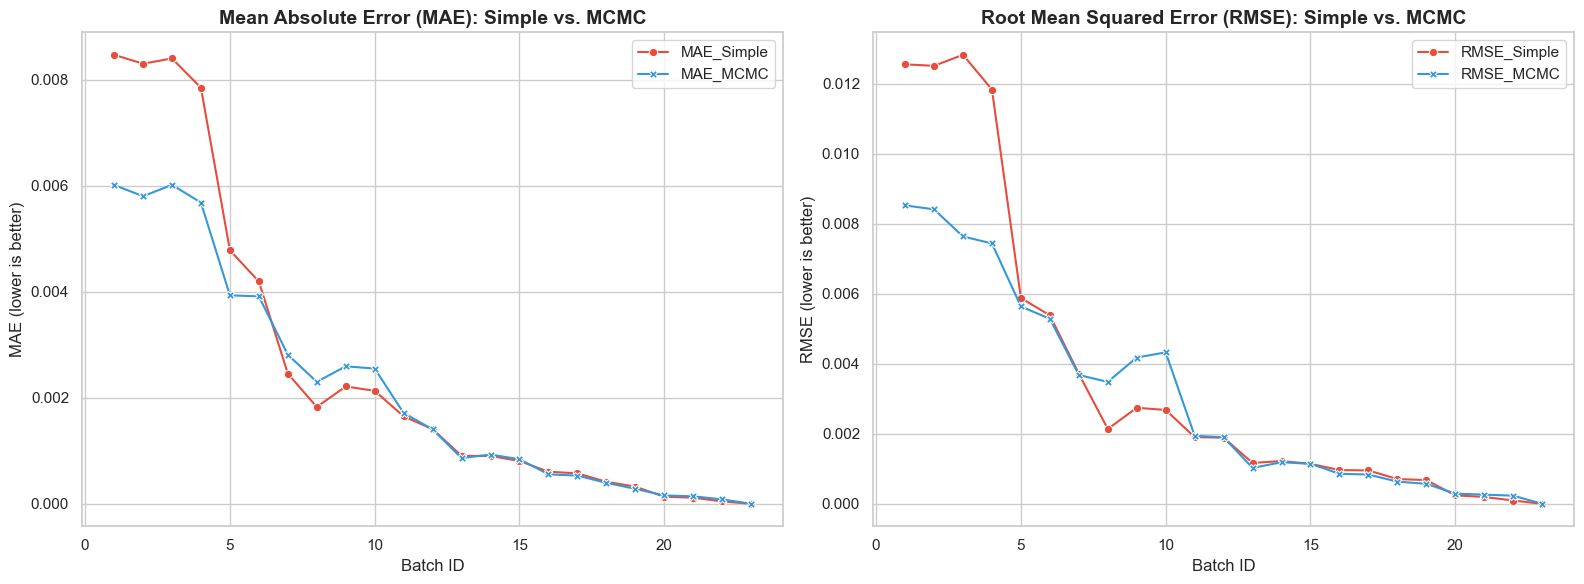

In [71]:
actual_final_props = race_data.sort_values('race_id')['final_dem_proportion'].values
race_denominators = race_data.sort_values('race_id')['final_total_votes'].values

mcmc_records = []

# 2. Loop through our simulated predictions
for batch_id in batches:
    # Get the 1000 simulations for this batch (Shape: 1000 simulations x 13 races)
    mcmc_sims = final_outcomes_dict[batch_id] 
    
    # Take the median projection for each race across the 1000 simulations
    mcmc_pred_votes = np.median(mcmc_sims, axis=0)
    
    # Convert raw votes to proportions
    mcmc_pred_prop = mcmc_pred_votes / race_denominators
    
    # Calculate Absolute and Squared Errors
    abs_errors = np.abs(mcmc_pred_prop - actual_final_props)
    sq_errors = (mcmc_pred_prop - actual_final_props) ** 2
    
    # Average the errors across all 13 races for this batch
    mcmc_records.append({
        'batch_id': batch_id,
        'MAE_MCMC': np.mean(abs_errors),
        'MSE_MCMC': np.mean(sq_errors)
    })

# 3. Build the dataframe and calculate RMSE
mcmc_error_summary = pd.DataFrame(mcmc_records)
mcmc_error_summary['RMSE_MCMC'] = np.sqrt(mcmc_error_summary['MSE_MCMC'])
mcmc_error_summary = mcmc_error_summary.drop(columns=['MSE_MCMC'])

# 4. Merge MCMC errors with the Simple Baseline errors we just calculated
plot_df = pd.merge(simple_error_summary, mcmc_error_summary, on='batch_id', how='inner')

# --- THE FIX: Drop batch 0 from the dataframe before plotting ---
plot_df = plot_df[plot_df['batch_id'] != 0].copy()
ig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style="whitegrid")

# --- Plot 1: MAE ---
sns.lineplot(
    data=plot_df.set_index('batch_id')[['MAE_Simple', 'MAE_MCMC']], 
    markers=True, 
    dashes=False,
    ax=axes[0],
    palette=["#e74c3c", "#3498db"] # Red for Simple, Blue for MCMC
)
axes[0].set_title("Mean Absolute Error (MAE): Simple vs. MCMC", fontsize=14, fontweight='bold')
axes[0].set_ylabel("MAE (lower is better)", fontsize=12)
axes[0].set_xlabel("Batch ID", fontsize=12)

# --- Plot 2: RMSE ---
sns.lineplot(
    data=plot_df.set_index('batch_id')[['RMSE_Simple', 'RMSE_MCMC']], 
    markers=True, 
    dashes=False,
    ax=axes[1],
    palette=["#e74c3c", "#3498db"] 
)
axes[1].set_title("Root Mean Squared Error (RMSE): Simple vs. MCMC", fontsize=14, fontweight='bold')
axes[1].set_ylabel("RMSE (lower is better)", fontsize=12)
axes[1].set_xlabel("Batch ID", fontsize=12)

plt.tight_layout()
plt.show()

Calculating full calibration curve...
Total predictions checked: 227
Average Variance of Simulated Next Batch: 0.009219
Average Squared Error of Actual Updates:  0.006578


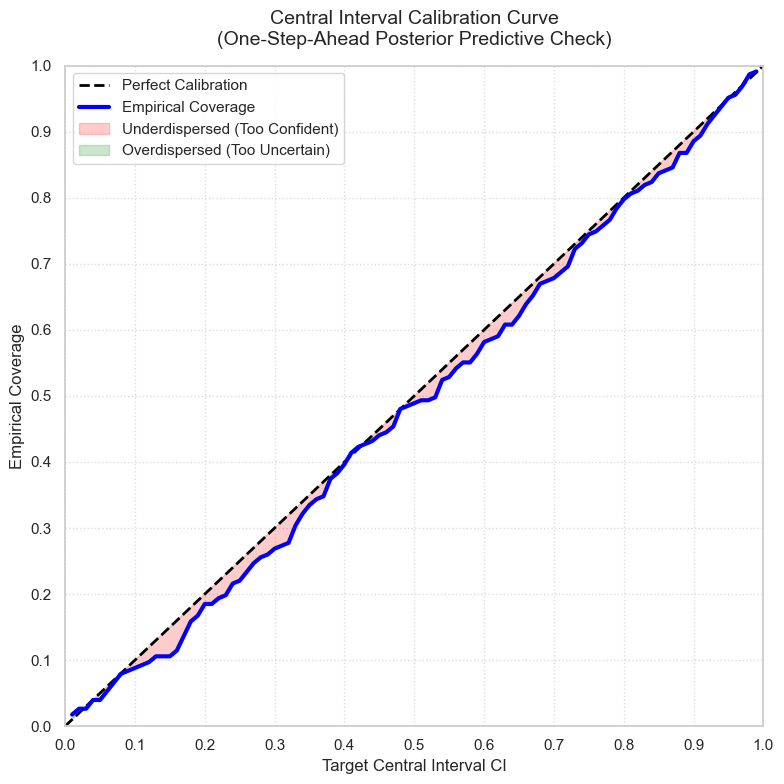

In [72]:
print("Calculating full calibration curve...")

# 1. Define every target interval from 1% to 99%
target_intervals = np.linspace(0.01, 0.99, 99)
in_interval_counts = np.zeros(len(target_intervals))
total_checks = 0

simulated_variances = []
observed_jumps = []

# 2. Iterate through batches to evaluate one-step-ahead predictions
for i in range(len(batches) - 1):
    current_batch = batches[i]
    next_batch = batches[i+1]
    
    # Shape: (1000, n_races)
    sim_next_rates = simulated_future_batches[current_batch][:, 0, :]
    
    # Calculate all lower and upper percentiles at once for this batch
    alphas = 1.0 - target_intervals
    lower_pcts = (alphas / 2.0) * 100
    upper_pcts = (1.0 - alphas / 2.0) * 100
    
    # Shapes will be (99, n_races)
    low_bounds = np.percentile(sim_next_rates, lower_pcts, axis=0)
    up_bounds = np.percentile(sim_next_rates, upper_pcts, axis=0)
    
    # Get the actual observed data
    next_batch_data = model_data[model_data['batch_id'] == next_batch]
    
    for race_idx in range(n_races):
        race_row = next_batch_data[next_batch_data['race_id'] == race_idx]
        
        if not race_row.empty:
            obs_prop = race_row['this_batch_dem_proportion'].values[0]
            batch_total = race_row['this_batch_total_votes'].values[0]
            
            # Only evaluate valid drops
            if batch_total > 0 and not np.isnan(obs_prop):
                total_checks += 1
                
                # Check which of the 99 intervals the observation falls into
                is_inside = (obs_prop >= low_bounds[:, race_idx]) & (obs_prop <= up_bounds[:, race_idx])
                in_interval_counts += is_inside
                
                # Track variance metric
                sim_median = np.median(sim_next_rates[:, race_idx])
                simulated_variances.append(np.var(sim_next_rates[:, race_idx]))
                observed_jumps.append((obs_prop - sim_median)**2)

# 3. Compute empirical coverage for all intervals
empirical_coverage = in_interval_counts / total_checks if total_checks > 0 else np.zeros_like(target_intervals)

mean_sim_var = np.mean(simulated_variances)
mean_obs_var = np.mean(observed_jumps)

print(f"Total predictions checked: {total_checks}")
print(f"Average Variance of Simulated Next Batch: {mean_sim_var:.6f}")
print(f"Average Squared Error of Actual Updates:  {mean_obs_var:.6f}")

# 4. Plot the Calibration Curve
plt.figure(figsize=(8, 8))

# The ideal calibration line (y = x)
plt.plot([0, 1], [0, 1], color='black', linestyle='--', linewidth=2, label='Perfect Calibration')

# The empirical results
plt.plot(target_intervals, empirical_coverage, color='blue', linewidth=3, label='Empirical Coverage')

# Fill the area to highlight over/under dispersion
plt.fill_between(target_intervals, empirical_coverage, target_intervals, 
                 where=(empirical_coverage < target_intervals), interpolate=True, color='red', alpha=0.2, label='Underdispersed (Too Confident)')
plt.fill_between(target_intervals, empirical_coverage, target_intervals, 
                 where=(empirical_coverage > target_intervals), interpolate=True, color='green', alpha=0.2, label='Overdispersed (Too Uncertain)')

plt.title('Central Interval Calibration Curve\n(One-Step-Ahead Posterior Predictive Check)', fontsize=14, pad=15)
plt.xlabel('Target Central Interval CI', fontsize=12)
plt.ylabel('Empirical Coverage', fontsize=12)

# Set grid and limits
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xticks(np.arange(0, 1.1, 0.1))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc='upper left', fontsize=11)

plt.tight_layout()
plt.show()


--- RESULTS: VOTE-WEIGHTED SUM OF ABSOLUTE SLOPES ---
Observed Test Statistic T(y)  : 0.038543
Mean Simulated T(y_rep)       : 0.071916
P-value                       : 0.8290
CONCLUSION: Model PASSES. Vote-weighted temporal drift is within expected variance.


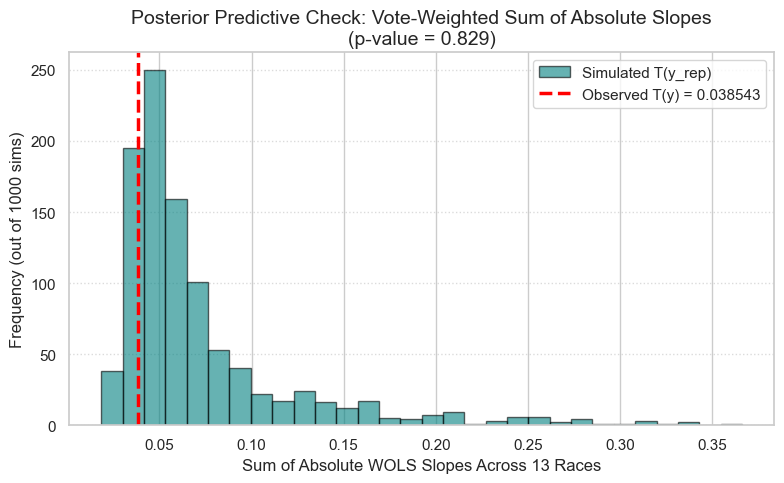

In [73]:
n_sims = 1000
n_time = len(batches) - 1

# 1. Initialize arrays (Now including weights!)
obs_props = np.full((n_races, n_time), np.nan)
obs_weights = np.full((n_races, n_time), np.nan)
sim_props = np.full((n_sims, n_races, n_time), np.nan)

# 2. Extract predictions, observations, and weights
for t_idx in range(n_time):
    current_batch = batches[t_idx]
    next_batch = batches[t_idx+1]
    
    sim_props[:, :, t_idx] = simulated_future_batches[current_batch][:, 0, :]
    
    next_batch_data = model_data[model_data['batch_id'] == next_batch]
    for race_idx in range(n_races):
        race_row = next_batch_data[next_batch_data['race_id'] == race_idx]
        if not race_row.empty:
            batch_total = race_row['this_batch_total_votes'].values[0]
            if batch_total > 0:  
                obs_props[race_idx, t_idx] = race_row['this_batch_dem_proportion'].values[0]
                obs_weights[race_idx, t_idx] = batch_total  # Save the vote count as the weight

# 3. Initialize our Test Statistics
T_obs = 0.0
T_sims = np.zeros(n_sims)
t_indices = np.arange(n_time)

# 4. Calculate WOLS regressions for each race
for race_idx in range(n_races):
    valid_mask = ~np.isnan(obs_props[race_idx])
    x = t_indices[valid_mask]
    w = obs_weights[race_idx, valid_mask]
    
    # We need at least 2 points to fit a line, and total weight > 0
    if len(x) < 2 or np.sum(w) == 0:
        continue
        
    # Pre-calculate the WOLS Denominator
    x_wmean = np.average(x, weights=w)
    x_dev = x - x_wmean
    SS_x_w = np.sum(w * (x_dev**2))
    
    if SS_x_w == 0:
        continue
        
    # --- OBSERVED WOLS SLOPE ---
    y_obs = obs_props[race_idx, valid_mask]
    y_obs_wmean = np.average(y_obs, weights=w)
    
    # Formula: Sum(w * (x - x_mean) * (y - y_mean)) / SS_x_w
    beta_obs = np.sum(w * x_dev * (y_obs - y_obs_wmean)) / SS_x_w
    T_obs += np.abs(beta_obs)
    
    # --- SIMULATED WOLS SLOPES (Vectorized) ---
    y_sims = sim_props[:, race_idx, valid_mask] # Shape: (1000, n_valid)
    
    # Calculate weighted mean across the valid batches for all 1000 sims
    y_sims_wmean = np.average(y_sims, weights=w, axis=1) # Shape: (1000,)
    y_sims_wmean = y_sims_wmean[:, np.newaxis]           # Shape: (1000, 1) for broadcasting
    
    # Calculate 1000 weighted slopes instantly
    betas_sim = np.sum(w * x_dev * (y_sims - y_sims_wmean), axis=1) / SS_x_w
    T_sims += np.abs(betas_sim)

# 5. Calculate Posterior Predictive p-value
p_val = np.mean(T_sims >= T_obs)

print("\n--- RESULTS: VOTE-WEIGHTED SUM OF ABSOLUTE SLOPES ---")
print(f"Observed Test Statistic T(y)  : {T_obs:.6f}")
print(f"Mean Simulated T(y_rep)       : {np.mean(T_sims):.6f}")
print(f"P-value                       : {p_val:.4f}")

if p_val <= 0.05:
    print("CONCLUSION: Model REJECTED. Significant vote-weighted linear drift detected across races.")
elif p_val >= 0.95:
    print("CONCLUSION: Anomalous lack of drift. The real data is suspiciously flat.")
else:
    print("CONCLUSION: Model PASSES. Vote-weighted temporal drift is within expected variance.")

# 6. Visualize the Test Statistic Distribution
plt.figure(figsize=(8, 5))
plt.hist(T_sims, bins=30, color='teal', alpha=0.6, edgecolor='black', label='Simulated T(y_rep)')
plt.axvline(T_obs, color='red', linestyle='--', linewidth=2.5, label=f'Observed T(y) = {T_obs:.6f}')

plt.title(f'Posterior Predictive Check: Vote-Weighted Sum of Absolute Slopes\n(p-value = {p_val:.3f})', fontsize=14)
plt.xlabel('Sum of Absolute WOLS Slopes Across 13 Races', fontsize=12)
plt.ylabel('Frequency (out of 1000 sims)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(axis='y', linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

Running k-Step-Ahead Calibration Decay PPC (Percentile Dispersion)...

--- RESULTS: PERCENTILE CALIBRATION DECAY ---
Total (origin, target) pairs evaluated: 2902
Observed Percentile Decay Slope per step k : 0.000047
Mean Simulated Decay Slope                 : 0.000000
P-value                                    : 0.4020
CONCLUSION: PASS. The dispersion of the model remains well-calibrated across horizons.


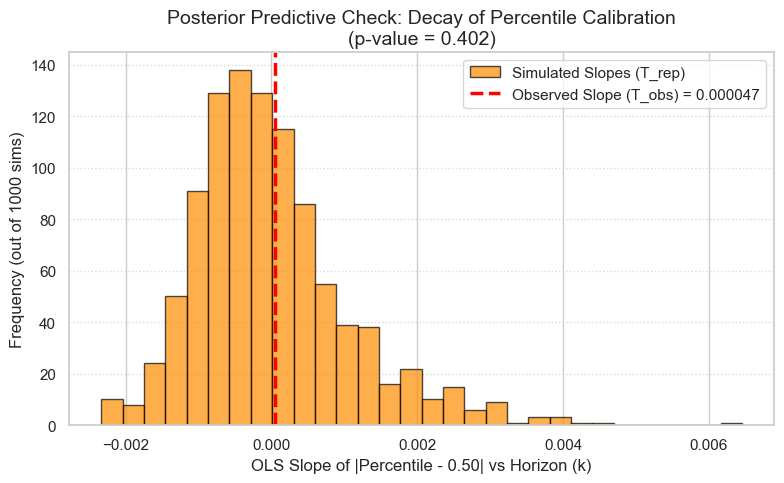

In [74]:
import numpy as np
from scipy.stats import rankdata
import matplotlib.pyplot as plt

print("Running k-Step-Ahead Calibration Decay PPC (Percentile Dispersion)...")

n_sims = 1000
n_time = len(batches) - 1

# 1. Lists to store our paired (Horizon k, Percentile Metrics)
k_values = []
obs_metrics = []
sim_metrics_dict = {s: [] for s in range(n_sims)}

# 2. Iterate through all origin batches (t)
for t_idx in range(n_time):
    current_batch = batches[t_idx]
    
    # Grab the simulated futures from this batch onward
    sims_from_t = simulated_future_batches[current_batch]
    n_future = sims_from_t.shape[1]
    
    # 3. Iterate through all available horizons (k) from this origin
    for k_idx in range(n_future):
        k = k_idx + 1 # Horizon
        target_batch = batches[t_idx + k]
        
        target_data = model_data[model_data['batch_id'] == target_batch]
        
        for race_idx in range(n_races):
            race_row = target_data[target_data['race_id'] == race_idx]
            
            if not race_row.empty:
                batch_total = race_row['this_batch_total_votes'].values[0]
                
                if batch_total > 0:
                    obs_prop = race_row['this_batch_dem_proportion'].values[0]
                    
                    if not np.isnan(obs_prop):
                        # Extract the 1000 sims for this specific target batch
                        sim_props = sims_from_t[:, k_idx, race_idx]
                        
                        # --- OBSERVED METRIC ---
                        # Percentile of the actual observation within the simulations (0.0 to 1.0)
                        obs_pct = np.mean(sim_props <= obs_prop)
                        obs_metric = np.abs(obs_pct - 0.50)
                        
                        # --- SIMULATED METRICS ---
                        # For the simulated paths, the percentile is just their rank / 1000
                        sim_ranks = rankdata(sim_props)
                        sim_pcts = sim_ranks / n_sims
                        sim_metric_array = np.abs(sim_pcts - 0.50)
                        
                        # Append to our regression tracking lists
                        k_values.append(k)
                        obs_metrics.append(obs_metric)
                        for s in range(n_sims):
                            sim_metrics_dict[s].append(sim_metric_array[s])

# Convert to arrays for vectorized OLS
k_array = np.array(k_values)
obs_Y = np.array(obs_metrics)
sim_Y_matrix = np.array([sim_metrics_dict[s] for s in range(n_sims)]) # Shape: (1000, n_pairs)

# 4. Calculate OLS Slopes (Abs Percentile Diff vs Horizon k)
k_mean = np.mean(k_array)
k_dev = k_array - k_mean
SS_k = np.sum(k_dev**2)

# Observed Slope
obs_Y_mean = np.mean(obs_Y)
T_obs_slope = np.sum(k_dev * (obs_Y - obs_Y_mean)) / SS_k

# Simulated Slopes (Vectorized)
sim_Y_means = np.mean(sim_Y_matrix, axis=1, keepdims=True)
T_sim_slopes = np.sum(k_dev * (sim_Y_matrix - sim_Y_means), axis=1) / SS_k

# 5. Calculate p-value (1-sided test: is observed slope significantly more positive?)
p_val = np.mean(T_sim_slopes >= T_obs_slope)

print("\n--- RESULTS: PERCENTILE CALIBRATION DECAY ---")
print(f"Total (origin, target) pairs evaluated: {len(k_array)}")
print(f"Observed Percentile Decay Slope per step k : {T_obs_slope:.6f}")
print(f"Mean Simulated Decay Slope                 : {np.mean(T_sim_slopes):.6f}")
print(f"P-value                                    : {p_val:.4f}")

if p_val <= 0.05:
    print("CONCLUSION: SEVERE DECAY. The model's predictions increasingly drift into the extreme tails as the horizon extends.")
else:
    print("CONCLUSION: PASS. The dispersion of the model remains well-calibrated across horizons.")

# 6. Visualize the Test Statistic
plt.figure(figsize=(8, 5))
plt.hist(T_sim_slopes, bins=30, color='darkorange', alpha=0.7, edgecolor='black', label='Simulated Slopes (T_rep)')
plt.axvline(T_obs_slope, color='red', linestyle='--', linewidth=2.5, label=f'Observed Slope (T_obs) = {T_obs_slope:.6f}')

plt.title(f'Posterior Predictive Check: Decay of Percentile Calibration\n(p-value = {p_val:.3f})', fontsize=14)
plt.xlabel('OLS Slope of |Percentile - 0.50| vs Horizon (k)', fontsize=12)
plt.ylabel('Frequency (out of 1000 sims)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(axis='y', linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

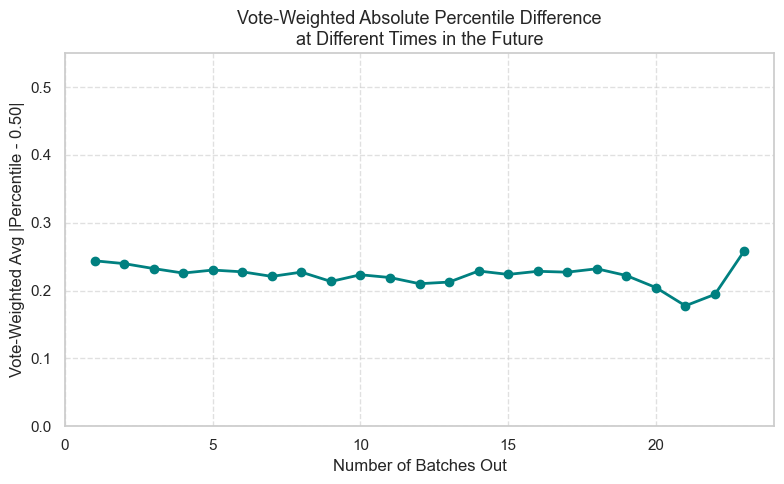

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import rankdata

# 1. Add lists to track our values and weights
k_values = []
obs_metrics = []
weights = [] # <-- Changed: Track the raw batch size

# 2. Iterate through to collect the data
n_time = len(batches) - 1
for t_idx in range(n_time):
    current_batch = batches[t_idx]
    sims_from_t = simulated_future_batches[current_batch]
    n_future = sims_from_t.shape[1]
    
    for k_idx in range(n_future):
        k = k_idx + 1 # Horizon
        target_batch = batches[t_idx + k]
        target_data = model_data[model_data['batch_id'] == target_batch]
        
        for race_idx in range(n_races):
            race_row = target_data[target_data['race_id'] == race_idx]
            
            if not race_row.empty:
                batch_total = race_row['this_batch_total_votes'].values[0]
                
                if batch_total > 0:
                    obs_prop = race_row['this_batch_dem_proportion'].values[0]
                    
                    if not np.isnan(obs_prop):
                        sim_props = sims_from_t[:, k_idx, race_idx]
                        
                        # Calculate the absolute percentile difference
                        obs_pct = np.mean(sim_props <= obs_prop)
                        obs_metric = np.abs(obs_pct - 0.50)

                        # Save to lists
                        k_values.append(k)
                        obs_metrics.append(obs_metric)
                        weights.append(batch_total) # <-- Changed: Use actual vote count

# 3. Build the DataFrame
zk = pd.DataFrame({
    "k": k_values, 
    "Abs_Pct_Diff": obs_metrics,
    "Weight": weights
})

# 4. Calculate the vote-weighted mean for each horizon (k)
weighted_means = zk.groupby("k").apply(
    lambda x: np.average(x["Abs_Pct_Diff"], weights=x["Weight"])
)

# 5. Plot the results
fig, ax = plt.subplots(figsize=(8, 5))
weighted_means.plot(ax=ax, marker='o', linewidth=2, color='teal')

ax.set_xlabel("Number of Batches Out", fontsize=12)
ax.set_ylabel("Vote-Weighted Avg |Percentile - 0.50|", fontsize=12)
ax.set_xlim((0, 24))
ax.set_ylim((0, 0.55)) 
ax.set_title("Vote-Weighted Absolute Percentile Difference\nat Different Times in the Future", fontsize=13)

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()